<a href="https://colab.research.google.com/github/krustybeast/sgx-bank-stock-analysis/blob/main/SGX_Stock_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install yfinance


In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

tickers = {
    'D05.SI': 'DBS Group',
    'O39.SI': 'OCBC',
    'U11.SI': 'UOB'
}

start_date = '2023-01-01'
end_date = '2026-09-05'  # today

raw_data = yf.download(list(tickers.keys()), start=start_date, end=end_date)

close_prices = raw_data['Close']
close_prices.columns = [tickers[t] for t in close_prices.columns]

print(close_prices.head())
print(close_prices.tail())
print(f"\nShape: {close_prices.shape}")
print(f"Missing values per stock:\n{close_prices.isna().sum()}")

/tmp/ipykernel_2278/2200489855.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(list(tickers.keys()), start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed

            DBS Group       OCBC        UOB
Date                                       
2023-01-03  24.560150   9.776263  24.706919
2023-01-04  24.661638   9.816197  24.513771
2023-01-05  25.212572   9.936005  24.924212
2023-01-06  24.987850   9.983930  24.819590
2023-01-09  25.553286  10.143670  24.682775
            DBS Group   OCBC        UOB
Date                                   
2026-08-31  77.400002  31.52  41.560001
2026-09-01  76.910004  31.34  41.419998
2026-09-02  77.599998  31.85  41.770000
2026-09-03  77.949997  31.92  41.740002
2026-09-04  78.650002  32.27  42.009998

Shape: (923, 3)
Missing values per stock:
DBS Group    0
OCBC         0
UOB          0
dtype: int64


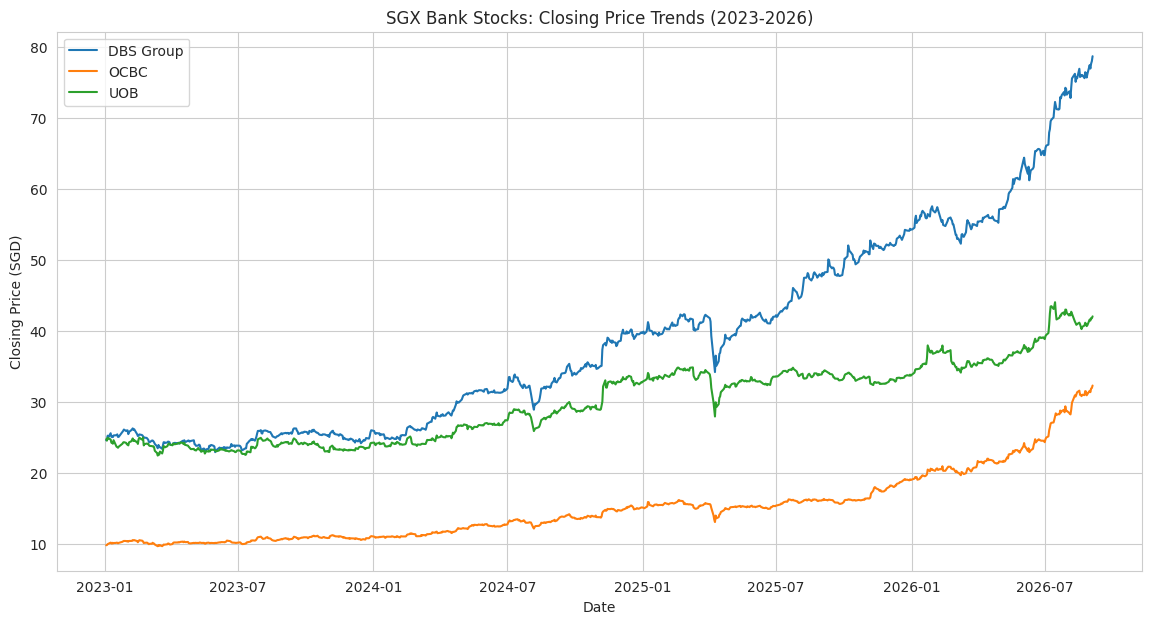

In [6]:
plt.figure(figsize=(14, 7))
for stock in close_prices.columns:
    plt.plot(close_prices.index, close_prices[stock], label=stock)

plt.title('SGX Bank Stocks: Closing Price Trends (2023-2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price (SGD)')
plt.legend()
plt.show()

            DBS Group      OCBC       UOB
Date                                     
2023-01-04   0.004132  0.004085 -0.007818
2023-01-05   0.022340  0.012205  0.016743
2023-01-06  -0.008913  0.004823 -0.004198
2023-01-09   0.022628  0.016000 -0.005512
2023-01-10  -0.019575 -0.012598 -0.018585

Summary statistics:
        DBS Group        OCBC         UOB
count  922.000000  922.000000  922.000000
mean     0.001320    0.001344    0.000625
std      0.010635    0.009778    0.009944
min     -0.080094   -0.069194   -0.062888
25%     -0.004304   -0.003881   -0.003907
50%      0.000923    0.000759    0.000125
75%      0.006169    0.006309    0.005391
max      0.067546    0.070042    0.071772


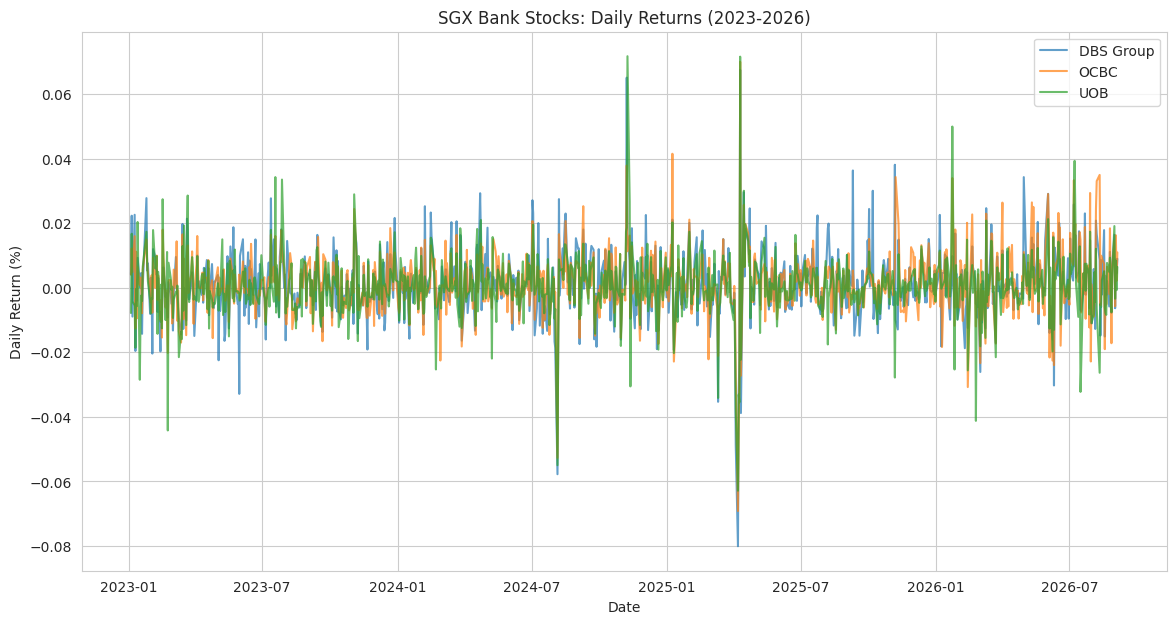

In [7]:
daily_returns = close_prices.pct_change().dropna()

print(daily_returns.head())
print(f"\nSummary statistics:\n{daily_returns.describe()}")

plt.figure(figsize=(14, 7))
for stock in daily_returns.columns:
    plt.plot(daily_returns.index, daily_returns[stock], label=stock, alpha=0.7)

plt.title('SGX Bank Stocks: Daily Returns (2023-2026)')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.legend()
plt.show()

In [8]:
risk_adjusted_return = daily_returns.mean() / daily_returns.std()
print("Risk-adjusted return (mean/std) per stock:")
print(risk_adjusted_return.sort_values(ascending=False))

Risk-adjusted return (mean/std) per stock:
OCBC         0.137421
DBS Group    0.124085
UOB          0.062876
dtype: float64


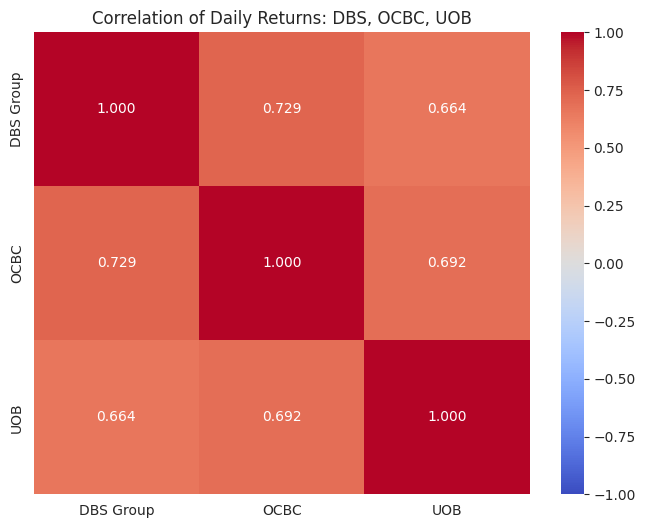

           DBS Group      OCBC       UOB
DBS Group   1.000000  0.729334  0.663640
OCBC        0.729334  1.000000  0.692243
UOB         0.663640  0.692243  1.000000


In [9]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Correlation of Daily Returns: DBS, OCBC, UOB')
plt.show()

print(correlation_matrix)

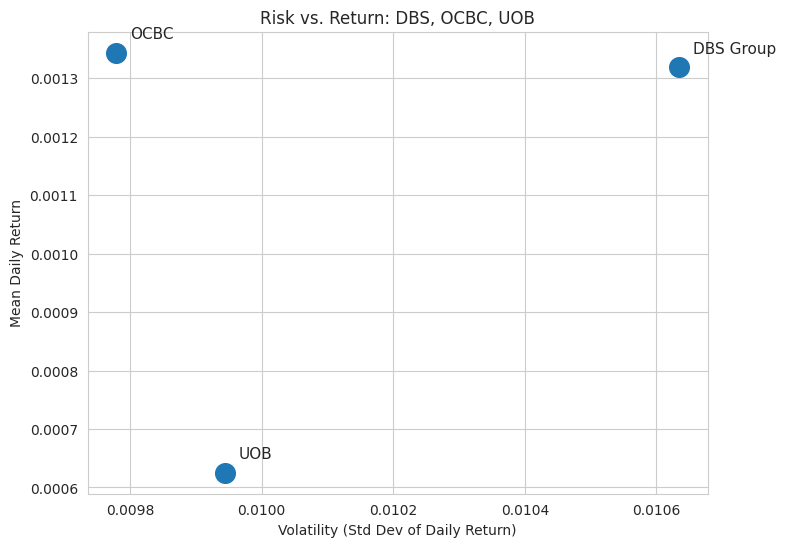

In [10]:
mean_returns = daily_returns.mean()
volatility = daily_returns.std()

plt.figure(figsize=(8, 6))
plt.scatter(volatility, mean_returns, s=200)

for stock in daily_returns.columns:
    plt.annotate(stock, (volatility[stock], mean_returns[stock]),
                 xytext=(10, 10), textcoords='offset points', fontsize=11)

plt.xlabel('Volatility (Std Dev of Daily Return)')
plt.ylabel('Mean Daily Return')
plt.title('Risk vs. Return: DBS, OCBC, UOB')
plt.grid(True)
plt.show()

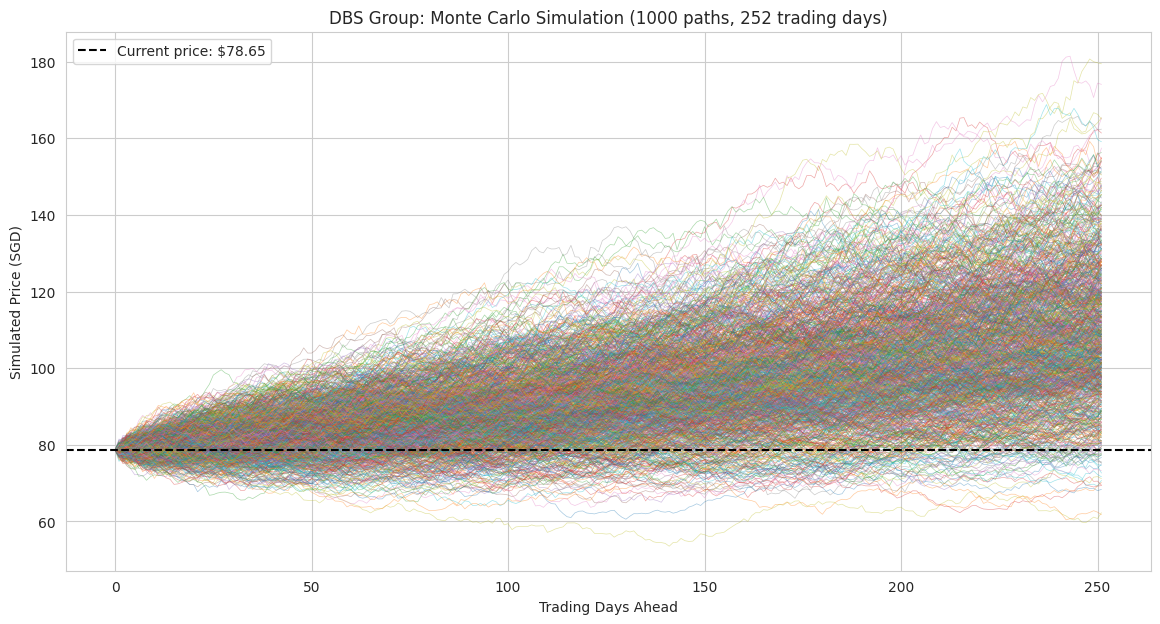

Current price: $78.65
Mean simulated price after 252 days: $109.48
5th percentile (pessimistic case): $81.93
95th percentile (optimistic case): $142.07


In [11]:
import numpy as np

# Parameters from DBS's historical data
stock_name = 'DBS Group'
last_price = close_prices[stock_name].iloc[-1]
mu = daily_returns[stock_name].mean()       # average daily return (drift)
sigma = daily_returns[stock_name].std()     # daily volatility

# Simulation settings
num_simulations = 1000
num_days = 252  # ~1 trading year ahead

np.random.seed(42)  # for reproducible results

simulation_results = np.zeros((num_days, num_simulations))
simulation_results[0] = last_price

for sim in range(num_simulations):
    for day in range(1, num_days):
        random_shock = np.random.normal(0, 1)
        daily_return = mu + sigma * random_shock
        simulation_results[day, sim] = simulation_results[day - 1, sim] * (1 + daily_return)

# Plot all simulated paths
plt.figure(figsize=(14, 7))
plt.plot(simulation_results, linewidth=0.5, alpha=0.4)
plt.axhline(y=last_price, color='black', linestyle='--', label=f'Current price: ${last_price:.2f}')
plt.title(f'{stock_name}: Monte Carlo Simulation ({num_simulations} paths, {num_days} trading days)')
plt.xlabel('Trading Days Ahead')
plt.ylabel('Simulated Price (SGD)')
plt.legend()
plt.show()

# Distribution of final simulated prices
final_prices = simulation_results[-1]
print(f"Current price: ${last_price:.2f}")
print(f"Mean simulated price after {num_days} days: ${final_prices.mean():.2f}")
print(f"5th percentile (pessimistic case): ${np.percentile(final_prices, 5):.2f}")
print(f"95th percentile (optimistic case): ${np.percentile(final_prices, 95):.2f}")

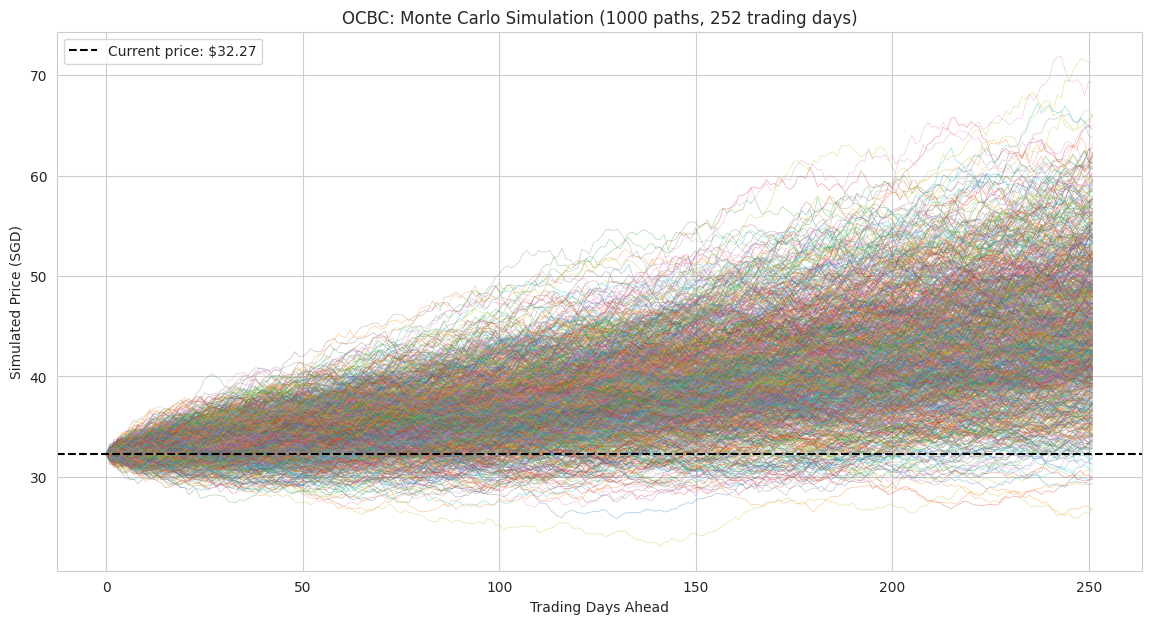

Current price: $32.27
Mean simulated price after 252 days: $45.20
5th percentile (pessimistic case): $34.66
95th percentile (optimistic case): $57.48


In [12]:
stock_name = 'OCBC'
last_price = close_prices[stock_name].iloc[-1]
mu = daily_returns[stock_name].mean()
sigma = daily_returns[stock_name].std()

np.random.seed(42)

simulation_results = np.zeros((num_days, num_simulations))
simulation_results[0] = last_price

for sim in range(num_simulations):
    for day in range(1, num_days):
        random_shock = np.random.normal(0, 1)
        daily_return = mu + sigma * random_shock
        simulation_results[day, sim] = simulation_results[day - 1, sim] * (1 + daily_return)

plt.figure(figsize=(14, 7))
plt.plot(simulation_results, linewidth=0.5, alpha=0.4)
plt.axhline(y=last_price, color='black', linestyle='--', label=f'Current price: ${last_price:.2f}')
plt.title(f'{stock_name}: Monte Carlo Simulation ({num_simulations} paths, {num_days} trading days)')
plt.xlabel('Trading Days Ahead')
plt.ylabel('Simulated Price (SGD)')
plt.legend()
plt.show()

final_prices = simulation_results[-1]
print(f"Current price: ${last_price:.2f}")
print(f"Mean simulated price after {num_days} days: ${final_prices.mean():.2f}")
print(f"5th percentile (pessimistic case): ${np.percentile(final_prices, 5):.2f}")
print(f"95th percentile (optimistic case): ${np.percentile(final_prices, 95):.2f}")

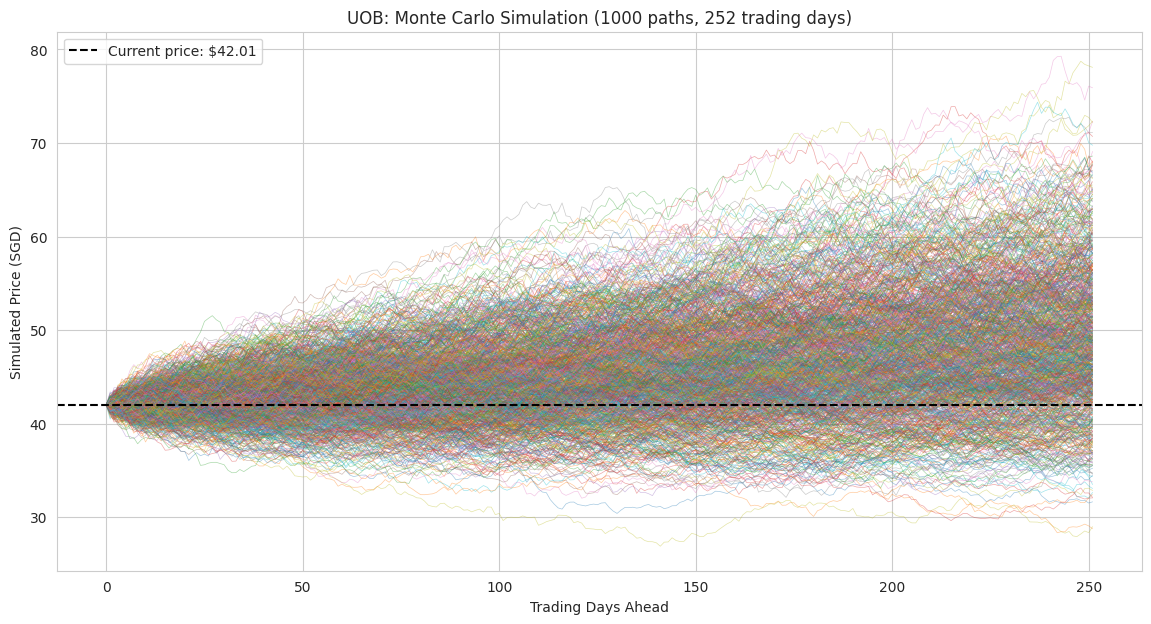

Current price: $42.01
Mean simulated price after 252 days: $49.14
5th percentile (pessimistic case): $37.49
95th percentile (optimistic case): $62.75


In [13]:
stock_name = 'UOB'
last_price = close_prices[stock_name].iloc[-1]
mu = daily_returns[stock_name].mean()
sigma = daily_returns[stock_name].std()

np.random.seed(42)

simulation_results = np.zeros((num_days, num_simulations))
simulation_results[0] = last_price

for sim in range(num_simulations):
    for day in range(1, num_days):
        random_shock = np.random.normal(0, 1)
        daily_return = mu + sigma * random_shock
        simulation_results[day, sim] = simulation_results[day - 1, sim] * (1 + daily_return)

plt.figure(figsize=(14, 7))
plt.plot(simulation_results, linewidth=0.5, alpha=0.4)
plt.axhline(y=last_price, color='black', linestyle='--', label=f'Current price: ${last_price:.2f}')
plt.title(f'{stock_name}: Monte Carlo Simulation ({num_simulations} paths, {num_days} trading days)')
plt.xlabel('Trading Days Ahead')
plt.ylabel('Simulated Price (SGD)')
plt.legend()
plt.show()

final_prices = simulation_results[-1]
print(f"Current price: ${last_price:.2f}")
print(f"Mean simulated price after {num_days} days: ${final_prices.mean():.2f}")
print(f"5th percentile (pessimistic case): ${np.percentile(final_prices, 5):.2f}")
print(f"95th percentile (optimistic case): ${np.percentile(final_prices, 95):.2f}")